# The three surrogate models

`RBFRegressor` fits all three models from the papers. Which one you get follows from the data you pass to `fit`:

| Call | Model |
| --- | --- |
| `fit(X, y)` | **FV** — function values only |
| `fit(X, y, dy=dy)` | **GE** — gradient-enhanced |
| `fit(X, dy=dy, anchor_X=..., anchor_y=...)` | **GO** — gradient-only |

We fit each to the same one-dimensional problem so the differences are visible.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import qmc

from ge_rbf import RBFRegressor


def underlying(x):
    """The function being approximated, and its gradient."""
    return np.sin(3 * np.pi * x), 3 * np.pi * np.cos(3 * np.pi * x)


# Latin hypercube sampling. scipy provides this, so no extra dependency is needed.
X = qmc.LatinHypercube(d=1, seed=3).random(9)
y, dy = underlying(X)
y = y.ravel()  # function values are (n_samples,), gradients are (n_samples, n_features)

x_dense = np.linspace(0, 1, 300).reshape(-1, 1)
y_dense, _ = underlying(x_dense)

X.shape, y.shape, dy.shape

((9, 1), (9,), (9, 1))

## Function value model

One centre per sample, so the fit interpolates the data exactly.

In [2]:
fv = RBFRegressor(epsilon=1.0).fit(X, y)

print(f"mode: {fv.mode_}, condition number: {fv.condition_:.3e}")
print(f"interpolation error at the samples: {np.abs(fv.predict(X) - y).max():.2e}")

mode: fv, condition number: 9.907e+13
interpolation error at the samples: 2.68e-06


## Gradient-enhanced model

Adding gradients gives `n_samples * (1 + n_features)` equations for `n_samples` weights, so the system is over-determined and solved in the least-squares sense. The fit no longer interpolates, but it knows the slope at every sample.

In [3]:
ge = RBFRegressor(epsilon=0.5).fit(X, y, dy=dy)

print(f"mode: {ge.mode_}, condition number: {ge.condition_:.3e}")
print(
    f"gradient error at the samples: {np.linalg.norm(ge.predict_gradient(X) - dy) / np.linalg.norm(dy):.2%}"
)

mode: ge, condition number: 4.502e+14
gradient error at the samples: 0.83%


## Gradient-only model

Gradients alone fix the surrogate only up to an additive constant, so the fit needs an anchor: one location and the function value there. The anchor does not have to be a sampled point — `anchor_X=[[0.0]], anchor_y=[0.0]` would be a legitimate choice.

In [4]:
go = RBFRegressor(epsilon=0.5).fit(X, dy=dy, anchor_X=X[:1], anchor_y=y[:1])

print(f"mode: {go.mode_}, condition number: {go.condition_:.3e}")
print(f"value at the anchor: predicted {go.predict(X[:1])[0]:.4f}, actual {y[0]:.4f}")

mode: go, condition number: 1.862e+14
value at the anchor: predicted 0.0838, actual 0.0896


## Comparison

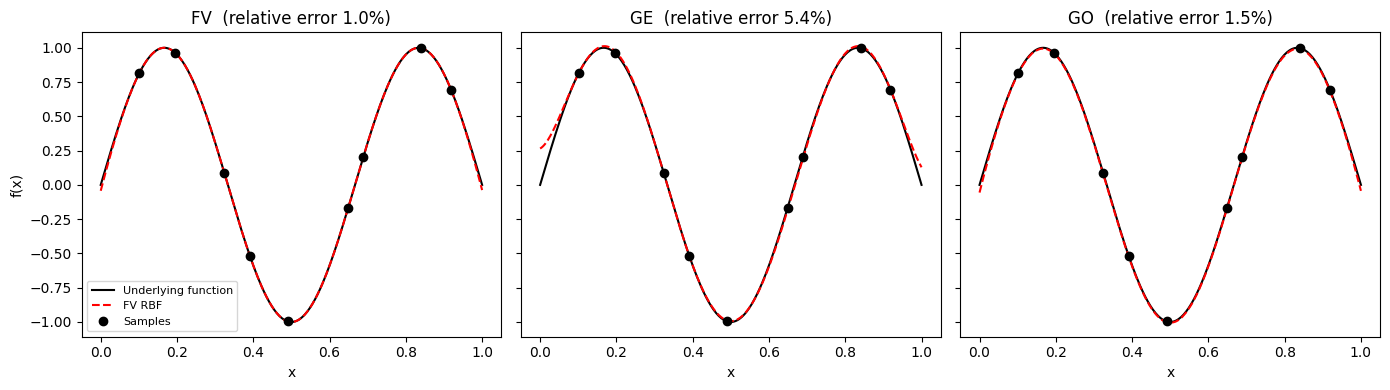

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (model, title) in zip(axes, [(fv, "FV"), (ge, "GE"), (go, "GO")], strict=True):
    ax.plot(x_dense, y_dense, "k", label="Underlying function")
    ax.plot(x_dense, model.predict(x_dense), "r--", label=f"{title} RBF")
    ax.plot(X, y, "ko", label="Samples")
    error = np.linalg.norm(model.predict(x_dense) - y_dense.ravel()) / np.linalg.norm(y_dense)
    ax.set_title(f"{title}  (relative error {error:.1%})")
    ax.set_xlabel("x")

axes[0].set_ylabel("f(x)")
axes[0].legend(loc="lower left", fontsize=8)
fig.tight_layout()

## Predicting gradients

Every model can report the gradient of its own surface, whether or not gradients were used to fit it. `predict(X, return_gradient=True)` returns both at once.

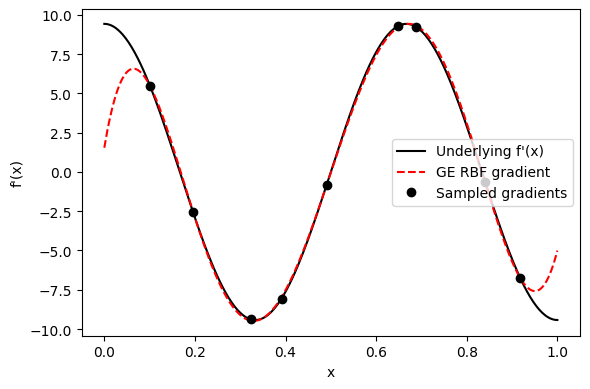

In [6]:
y_hat, dy_hat = ge.predict(x_dense, return_gradient=True)
_, dy_true = underlying(x_dense)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_dense, dy_true, "k", label="Underlying f'(x)")
ax.plot(x_dense, dy_hat, "r--", label="GE RBF gradient")
ax.plot(X, dy, "ko", label="Sampled gradients")
ax.set_xlabel("x")
ax.set_ylabel("f'(x)")
ax.legend()
fig.tight_layout()

## Fewer centres than samples

Placing a centre at every sample is the interpolating choice. Using fewer centres gives a regression fit, which is cheaper and less prone to fitting noise.

In [7]:
for step in (1, 2, 3):
    model = RBFRegressor(epsilon=1.0, centers=X[::step]).fit(X, y)
    residual = np.linalg.norm(model.predict(X) - y)
    print(
        f"{model.centers_.shape[0]:2d} centres -> training residual {residual:.3e}, condition {model.condition_:.2e}"
    )

 9 centres -> training residual 3.852e-06, condition 9.91e+13
 5 centres -> training residual 1.500e-01, condition 6.00e+05
 3 centres -> training residual 1.019e+00, condition 2.67e+03
